<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA60/blob/main/Mantzaris-Topic5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matrix shape: (200, 100),  sparsity: 65% zeros
CUR reconstruction error (k=10): 82.2424
PCA reconstruction error (k=3): 0.5698
PCA variance explained   (k=3): 49.3%
Figure saved: cur_vs_pca_SOLUTION.png


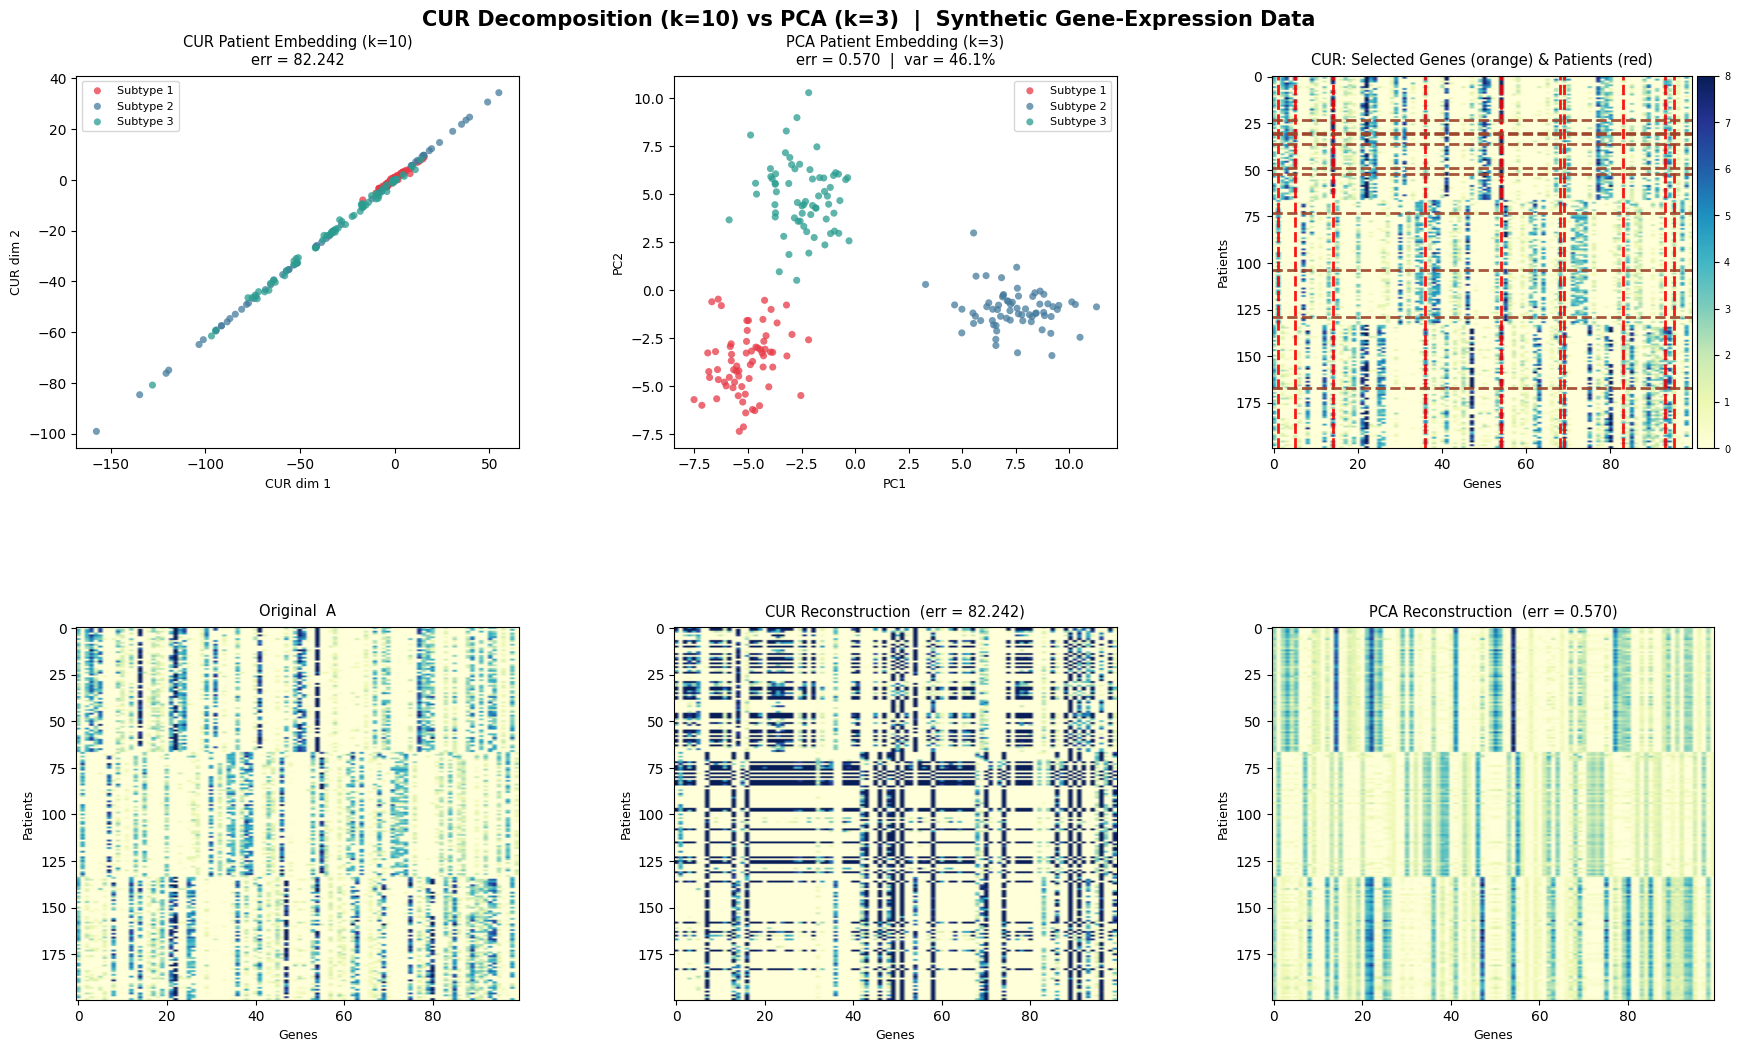

In [2]:
"""

     DAMA60/HW5/Topic 5
     Academic Year 2025-2026

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

CLR_SUBTYPE = ["#E63946", "#457B9D", "#2A9D8F"]
CLR_COL_SEL = "#F70000"
CLR_ROW_SEL = "#9D432A"
CLR_CMAP    = "YlGnBu"
CLR_VMIN, CLR_VMAX = 0, 8


def load_data(path="gene_expression_data.npz"):
    data = np.load(path)
    return data["A"], data["labels"]


A, true_labels = load_data("gene_expression_data.npz")

sparsity = np.mean(A == 0) * 100
print(f"Matrix shape: {A.shape},  sparsity: {sparsity:.0f}% zeros")


# --------------------- Part 1 - CUR implementation ---------------------

def cur_decomposition(A, k):
    n, m = A.shape
    frob_sq = np.sum(A ** 2)

    # Column sampling probabilities
    p = np.sum(A ** 2, axis=0) / frob_sq
    col_idx = np.random.choice(m, size=k, replace=False, p=p)
    C = A[:, col_idx]

    # Row sampling probabilities
    q = np.sum(A ** 2, axis=1) / frob_sq
    row_idx = np.random.choice(n, size=k, replace=False, p=q)
    R = A[row_idx, :]

    # Intersection matrix and pseudo-inverse
    W = A[np.ix_(row_idx, col_idx)]
    U = np.linalg.pinv(W)

    return C, U, R, col_idx, row_idx


# --------------------- Part 2 - CUR reconstruction ---------------------

K_CUR = 10
K_PCA = 3

C, U, R, col_idx, row_idx = cur_decomposition(A, K_CUR)

A_cur = C @ U @ R
err_cur = np.linalg.norm(A - A_cur, 'fro') / np.linalg.norm(A, 'fro')
scores_cur = (C @ U)[:, :2]

print(f"CUR reconstruction error (k={K_CUR}): {err_cur:.4f}")


# --------------------- Part 3 - PCA reconstruction ---------------------

scaler = StandardScaler()
A_scaled = scaler.fit_transform(A)

pca = PCA(n_components=K_PCA)
scores_pca = pca.fit_transform(A_scaled)
evr = pca.explained_variance_ratio_

A_pca_scaled = pca.inverse_transform(scores_pca)
A_pca = scaler.inverse_transform(A_pca_scaled)

err_pca = np.linalg.norm(A - A_pca, 'fro') / np.linalg.norm(A, 'fro')

print(f"PCA reconstruction error (k={K_PCA}): {err_pca:.4f}")
print(f"PCA variance explained   (k={K_PCA}): {evr.sum()*100:.1f}%")


# --------------------- Part 4 - Visualisation ---------------------

COLORS = CLR_SUBTYPE

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    f"CUR Decomposition (k={K_CUR}) vs PCA (k={K_PCA})  |  Synthetic Gene-Expression Data",
    fontsize=15, fontweight="bold", y=0.97
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.48, wspace=0.35,
    left=0.06, right=0.97, top=0.91, bottom=0.07
)


def style_ax(ax, title):
    ax.set_title(title, fontsize=10.5, pad=8)


ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, f"CUR Patient Embedding (k={K_CUR})\nerr = {err_cur:.3f}")

for cls, col in enumerate(COLORS):
    mask = true_labels == cls
    ax1.scatter(
        scores_cur[mask, 0],
        scores_cur[mask, 1],
        c=col,
        alpha=0.75,
        s=26,
        label=f"Subtype {cls + 1}",
        edgecolors="none"
    )

ax1.set_xlabel("CUR dim 1", fontsize=9)
ax1.set_ylabel("CUR dim 2", fontsize=9)
ax1.legend(fontsize=8)


ax2 = fig.add_subplot(gs[0, 1])
style_ax(
    ax2,
    f"PCA Patient Embedding (k={K_PCA})\n"
    f"err = {err_pca:.3f}  |  var = {100 * evr[:2].sum():.1f}%"
)

for cls, col in enumerate(COLORS):
    mask = true_labels == cls
    ax2.scatter(
        scores_pca[mask, 0],
        scores_pca[mask, 1],
        c=col,
        alpha=0.75,
        s=26,
        label=f"Subtype {cls + 1}",
        edgecolors="none"
    )

ax2.set_xlabel("PC1", fontsize=9)
ax2.set_ylabel("PC2", fontsize=9)
ax2.legend(fontsize=8)


ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, "CUR: Selected Genes (orange) & Patients (red)")

im3 = ax3.imshow(A, aspect="auto", cmap=CLR_CMAP, vmin=CLR_VMIN, vmax=CLR_VMAX)

for ci in col_idx:
    ax3.axvline(ci, color=CLR_COL_SEL, lw=2.0, ls="--", alpha=0.9)

for ri in row_idx:
    ax3.axhline(ri, color=CLR_ROW_SEL, lw=2.0, ls="--", alpha=0.9)

ax3.set_xlabel("Genes", fontsize=9)
ax3.set_ylabel("Patients", fontsize=9)

div = make_axes_locatable(ax3)
cax = div.append_axes("right", size="4%", pad=0.05)
cb = plt.colorbar(im3, cax=cax)
plt.setp(cb.ax.yaxis.get_ticklabels(), fontsize=7)


for ax, mat, lbl in [
    (fig.add_subplot(gs[1, 0]), A, "Original  A"),
    (fig.add_subplot(gs[1, 1]), A_cur, f"CUR Reconstruction  (err = {err_cur:.3f})"),
    (fig.add_subplot(gs[1, 2]), A_pca, f"PCA Reconstruction  (err = {err_pca:.3f})"),
]:
    style_ax(ax, lbl)
    ax.imshow(mat, aspect="auto", cmap=CLR_CMAP, vmin=CLR_VMIN, vmax=CLR_VMAX)
    ax.set_xlabel("Genes", fontsize=9)
    ax.set_ylabel("Patients", fontsize=9)


plt.savefig("cur_vs_pca_SOLUTION.png", dpi=150, bbox_inches="tight")
print("Figure saved: cur_vs_pca_SOLUTION.png")
plt.show()